# Word Cloud of "The Camellia (동백꽃)"

Load Data: Full text of The Camellia (동백꽃)

In [ ]:
with open('./data/ko_camellias.txt', encoding='utf-8') as f:
    text = f.read()

text[:200]

'오늘도 또 우리 수탉이 막 쫓기었다. 내가 점심을 먹고 나무를 하러 갈 양으로 나올 때이었다. 산으로 올라서려니까 등뒤에서 푸드득푸드득, 하고 닭의 횃소리가 야단이다. 깜짝 놀라서 고개를 돌려보니 아니나다르랴, 두 놈이 또 얼리었다.\n\n점순네 수탉(은 대강이가 크고 똑 오소리같이 실팍하게 생긴 놈)이 덩저리 작은 우리 수탉을 함부로 해내는 것이다. 그것도 '

### 1. Draw Wordcloud (without any text processing)

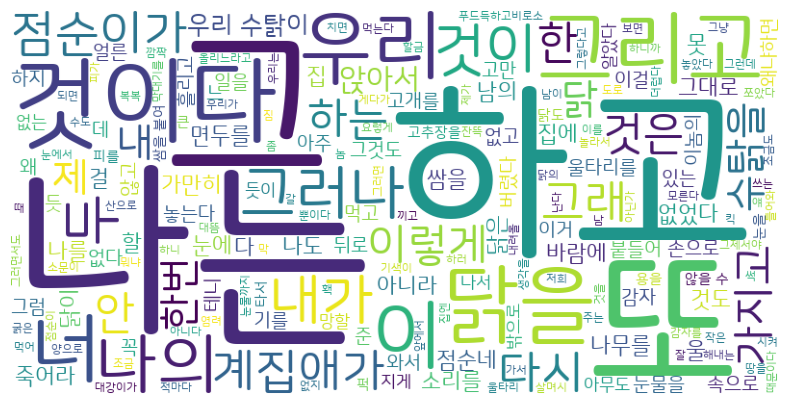

In [2]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# you have to set the font path for Korean text!
wordcloud = WordCloud(font_path='./NanumSquareRoundR.ttf', 
                      width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

### 2. Draw Wordcloud with an appropriate text processing

In [11]:
from konlpy.tag import Okt

def get_preprocessed_corpus(text, stopwords=None):

    okt = Okt()
    tagged = okt.pos(text, stem=True, norm=True)
    filtered = [w for w, pos in tagged if pos[0] in 'N']
    
    if stopwords is not None:
        filtered = [w for w in filtered if w not in stopwords]
    return ' '.join(filtered)


def draw_wordcloud(text):
    wordcloud = WordCloud(font_path='./NanumSquareRoundR.ttf', 
                          width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.show()

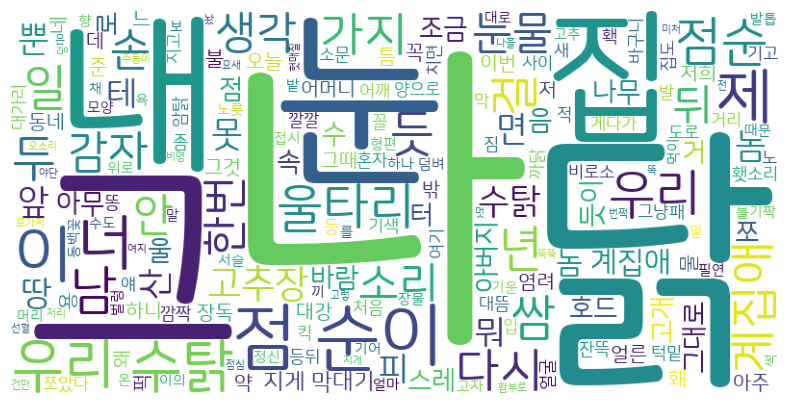

In [15]:
stopwords = ['것', '또', '때',]
text_preprocessed = get_preprocessed_corpus(text, stopwords=stopwords)
draw_wordcloud(text_preprocessed)